In [ ]:
import torch
print("GPU disponible:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU disponible: False
Device: CPU


In [ ]:
from google.colab import files
uploaded = files.upload()  # selecciona dinos.csv

Saving dinos.csv to dinos (1).csv


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/jpospinalo/MachineLearning/main/nlp/dinos.csv"
df = pd.read_csv(url, header=None, names=["nombre"])

# Exploración
nombres = df["nombre"].str.lower().tolist()

vocab = sorted(set("".join(nombres)))
print("Caracteres únicos:", vocab)
print("Tamaño del vocabulario:", len(vocab))

longitudes = [len(n) for n in nombres]
print(f"\nLongitud mínima: {min(longitudes)}")
print(f"Longitud máxima: {max(longitudes)}")
print(f"Longitud promedio: {sum(longitudes)/len(longitudes):.1f}")

Caracteres únicos: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Tamaño del vocabulario: 26

Longitud mínima: 3
Longitud máxima: 26
Longitud promedio: 12.0


In [ ]:
# Juntar todos los nombres en un solo string
nombres = df["nombre"].str.lower().tolist()

# Vocabulario de caracteres
vocab = sorted(set("".join(nombres)))
print("Caracteres únicos:", vocab)
print("Tamaño del vocabulario:", len(vocab))

# Longitud de nombres
longitudes = [len(n) for n in nombres]
print(f"\nLongitud mínima: {min(longitudes)}")
print(f"Longitud máxima: {max(longitudes)}")
print(f"Longitud promedio: {sum(longitudes)/len(longitudes):.1f}")

Caracteres únicos: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Tamaño del vocabulario: 26

Longitud mínima: 3
Longitud máxima: 26
Longitud promedio: 12.0


In [ ]:
# ── Preprocesamiento completo ──────────────────────────────────────────

# Tokens especiales
SOS   = "<SOS>"
EOS   = "<EOS>"
PAD   = "<PAD>"

# Vocabulario extendido con tokens especiales
chars = ['<PAD>', '<SOS>', '<EOS>'] + sorted(set("".join(nombres)))

char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

V = len(chars)
T = 26 + 2  # longitud máxima + SOS + EOS

print(f"Vocabulario total : {V} tokens")
print(f"Longitud máxima T : {T}")
print(f"char2idx (primeros 6): {dict(list(char2idx.items())[:6])}")

# ── Construcción de X e Y ─────────────────────────────────────────────
import numpy as np

def encode(nombre):
    tokens = [SOS] + list(nombre) + [EOS]
    # Padding hasta T
    tokens += [PAD] * (T - len(tokens))
    return [char2idx[c] for c in tokens]

X_data = []
Y_data = []

for nombre in nombres:
    seq = encode(nombre)
    X_data.append(seq[:-1])   # [SOS, c1, c2, ..., EOS-1] longitud T-1... espera
    Y_data.append(seq[1:])    # [c1, c2, ..., EOS, PAD...] shifted by 1

X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"\nShape X: {X_data.shape}")
print(f"Shape Y: {Y_data.shape}")

# Verificar con un ejemplo
print(f"\nEjemplo — nombre: '{nombres[0]}'")
print(f"X: {[idx2char[i] for i in X_data[0]]}")
print(f"Y: {[idx2char[i] for i in Y_data[0]]}")

Vocabulario total : 29 tokens
Longitud máxima T : 28
char2idx (primeros 6): {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, 'a': 3, 'b': 4, 'c': 5}

Shape X: (1536, 27)
Shape Y: (1536, 27)

Ejemplo — nombre: 'aachenosaurus'
X: ['<SOS>', 'a', 'a', 'c', 'h', 'e', 'n', 'o', 's', 'a', 'u', 'r', 'u', 's', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
Y: ['a', 'a', 'c', 'h', 'e', 'n', 'o', 's', 'a', 'u', 'r', 'u', 's', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


In [ ]:
  import torch
import torch.nn as nn

# ── Arquitectura ───────────────────────────────────────────────────────
class DinoRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm       = nn.LSTM(embed_dim, hidden_size, num_layers=num_layers,
                                  batch_first=True, dropout=dropout)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb    = self.embedding(x)           # (B, T, embed_dim)
        out, hidden = self.lstm(emb, hidden) # (B, T, hidden_size)
        logits = self.fc(out)                # (B, T, vocab_size)
        return logits, hidden

# ── Hiperparámetros ────────────────────────────────────────────────────
VOCAB_SIZE   = V            # 29
EMBED_DIM    = 64
HIDDEN_SIZE  = 256
NUM_LAYERS   = 2
BATCH_SIZE   = 64
EPOCHS       = 150
LR           = 0.003
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DinoRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
print(model)
print(f"\nDevice: {DEVICE}")
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters()):,}")

# ── DataLoader ─────────────────────────────────────────────────────────
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.tensor(X_data, dtype=torch.long)
Y_tensor = torch.tensor(Y_data, dtype=torch.long)

dataset    = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ── Entrenamiento ──────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=0)   # ignora PAD
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0

    for xb, yb in dataloader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(xb)                          # (B, T, V)
        loss = criterion(logits.view(-1, VOCAB_SIZE), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    scheduler.step()

    if epoch % 10 == 0:
        print(f"Época {epoch:3d}/{EPOCHS} — Loss: {avg_loss:.4f}")

print("\n✅ Entrenamiento completo")

DinoRNN(
  (embedding): Embedding(29, 64, padding_idx=0)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=29, bias=True)
)

Device: cpu
Parámetros entrenables: 865,373
Época  10/150 — Loss: 1.3031
Época  20/150 — Loss: 0.8277
Época  30/150 — Loss: 0.6876
Época  40/150 — Loss: 0.6530
Época  50/150 — Loss: 0.6407
Época  60/150 — Loss: 0.6088
Época  70/150 — Loss: 0.6065
Época  80/150 — Loss: 0.6068
Época  90/150 — Loss: 0.6027
Época 100/150 — Loss: 0.6009
Época 110/150 — Loss: 0.5924
Época 120/150 — Loss: 0.5910
Época 130/150 — Loss: 0.5897
Época 140/150 — Loss: 0.5896
Época 150/150 — Loss: 0.5902

✅ Entrenamiento completo


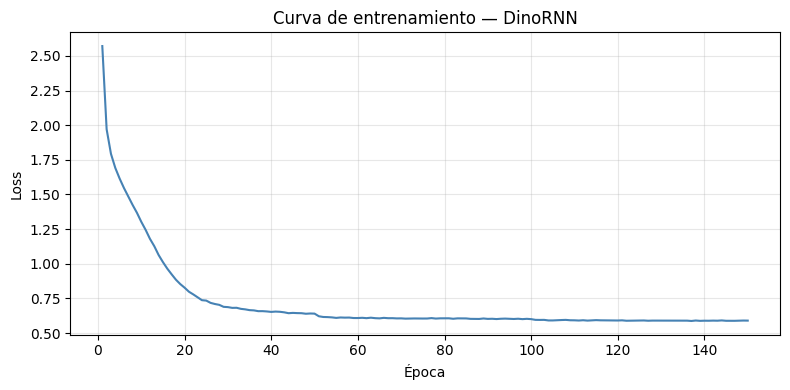

✅ Curva guardada


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), losses, color='steelblue', linewidth=1.5)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de entrenamiento — DinoRNN")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()
print("✅ Curva guardada")

In [ ]:
import torch.nn.functional as F

# ── Función de muestreo ────────────────────────────────────────────────
def generar_nombre(model, char2idx, idx2char, temperatura=1.0,
                   top_k=None, top_p=None, max_len=27):
    model.eval()
    with torch.no_grad():
        # Empezar con <SOS>
        x = torch.tensor([[char2idx['<SOS>']]], dtype=torch.long).to(DEVICE)
        hidden = None
        nombre = []

        for _ in range(max_len):
            logits, hidden = model(x, hidden)       # (1, 1, V)
            logits = logits[0, -1, :] / temperatura # escalar por temperatura

            # ── Top-k ──────────────────────────────────────────────────
            if top_k is not None:
                valores, _ = torch.topk(logits, top_k)
                umbral = valores[-1]
                logits[logits < umbral] = -float('inf')

            # ── Top-p (nucleus) ────────────────────────────────────────
            if top_p is not None:
                probs_sorted, indices_sorted = torch.sort(F.softmax(logits, dim=-1),
                                                          descending=True)
                acumulado = torch.cumsum(probs_sorted, dim=0)
                # Eliminar tokens que superen el umbral acumulado
                indices_eliminar = acumulado - probs_sorted > top_p
                logits[indices_sorted[indices_eliminar]] = -float('inf')

            # Muestrear
            probs = F.softmax(logits, dim=-1)
            siguiente = torch.multinomial(probs, 1).item()

            if siguiente == char2idx['<EOS>']:
                break
            if siguiente == char2idx['<PAD>']:
                break

            nombre.append(idx2char[siguiente])
            x = torch.tensor([[siguiente]], dtype=torch.long).to(DEVICE)

        return "".join(nombre)


# ── Generar con diferentes configuraciones ─────────────────────────────
configuraciones = [
    {"label": "Temperatura 0.7                ", "kwargs": {"temperatura": 0.7}},
    {"label": "Temperatura 1.0                ", "kwargs": {"temperatura": 1.0}},
    {"label": "Temperatura 2.5                ", "kwargs": {"temperatura": 2.5}},
    {"label": "Temperatura 4.0                ", "kwargs": {"temperatura": 4.0}},
    {"label": "Top-k=5,  temp=1.0             ", "kwargs": {"temperatura": 1.0, "top_k": 5}},
    {"label": "Top-k=10, temp=1.0             ", "kwargs": {"temperatura": 1.0, "top_k": 10}},
    {"label": "Top-p=0.8, temp=1.0            ", "kwargs": {"temperatura": 1.0, "top_p": 0.8}},
    {"label": "Top-p=0.95, temp=1.0           ", "kwargs": {"temperatura": 1.0, "top_p": 0.95}},
    {"label": "Top-k=10, Top-p=0.9, temp=0.7 ", "kwargs": {"temperatura": 0.7, "top_k": 10, "top_p": 0.9}},
]

print("=" * 55)
for cfg in configuraciones:
    nombres_gen = [generar_nombre(model, char2idx, idx2char, **cfg["kwargs"])
                   for _ in range(5)]
    print(f"\n{cfg['label']}")
    for n in nombres_gen:
        print(f"  → {n.capitalize()}")
print("=" * 55)


Temperatura 0.7                
  → Brachyrophus
  → Lepidocheirosaurus
  → Ornithotarsus
  → Procerosaurus
  → Rileya

Temperatura 1.0                
  → Tomodon
  → Futabasaurus
  → Microceratops
  → Cumnoria
  → Huxleysaurus

Temperatura 2.5                
  → Hoplosaurus
  → Hironosauhus
  → Touhasaurus
  → 
  → Puerosperux

Temperatura 4.0                
  → Yubacompsognalous
  → Swoelmasgis
  → Igcanohsauroc
  → Oshanuasaurus
  → Eoivechosuchus

Top-k=5,  temp=1.0             
  → Colepiocephale
  → Tangvayosaurus
  → Angulomastacator
  → Shantungosaurus
  → Coelurosauravus

Top-k=10, temp=1.0             
  → Melanorosaurus
  → Eucamerotus
  → Arctosaurus
  → Avalonia
  → Diabloceratops

Top-p=0.8, temp=1.0            
  → Amtosaurus
  → Nanuqsaurus
  → Sterrholophus
  → Paraiguanodon
  → Antarctopelta

Top-p=0.95, temp=1.0           
  → Dinotyrannus
  → Tongtianlong
  → Marisaurus
  → Ornithoides
  → Yunnanosaurus

Top-k=10, Top-p=0.9, temp=0.7 
  → Sanjuansaurus
  → Sphen

In [ ]:
# ── Top 10 nombres finales ─────────────────────────────────────────────
top10 = [
    {"nombre": "Tanystrosuchus",   "config": "Temperatura 0.7"},
    {"nombre": "Lignaveusaurus",   "config": "Temperatura 2.5"},
    {"nombre": "Poinavenator",     "config": "Temperatura 2.5"},
    {"nombre": "Sinocalliopteryx", "config": "Top-k=5, temp=1.0"},
    {"nombre": "Araucanoraptor",   "config": "Top-k=5, temp=1.0"},
    {"nombre": "Macrophalangia",   "config": "Top-p=0.8, temp=1.0"},
    {"nombre": "Saurophaganax",    "config": "Top-p=0.8, temp=1.0"},
    {"nombre": "Becklespinax",     "config": "Top-p=0.95, temp=1.0"},
    {"nombre": "Albertaceratops",  "config": "Top-k=10, Top-p=0.9, temp=0.7"},
    {"nombre": "Mantellodon",      "config": "Top-k=10, Top-p=0.9, temp=0.7"},
]

print("Top 10 nombres generados:")
for i, d in enumerate(top10, 1):
    print(f"  {i:2}. {d['nombre']:<22} ({d['config']})")

Top 10 nombres generados:
   1. Tanystrosuchus         (Temperatura 0.7)
   2. Lignaveusaurus         (Temperatura 2.5)
   3. Poinavenator           (Temperatura 2.5)
   4. Sinocalliopteryx       (Top-k=5, temp=1.0)
   5. Araucanoraptor         (Top-k=5, temp=1.0)
   6. Macrophalangia         (Top-p=0.8, temp=1.0)
   7. Saurophaganax          (Top-p=0.8, temp=1.0)
   8. Becklespinax           (Top-p=0.95, temp=1.0)
   9. Albertaceratops        (Top-k=10, Top-p=0.9, temp=0.7)
  10. Mantellodon            (Top-k=10, Top-p=0.9, temp=0.7)


In [ ]:
# ── Análisis comparativo ───────────────────────────────────────────────
analisis = """
La temperatura baja (0.7) produjo nombres conservadores y fonéticamente
plausibles como Tanystrosuchus, pero con menor originalidad. Temperaturas
altas (2.5–4.0) generaron combinaciones más creativas aunque con riesgo de
incoherencia fonética. Los métodos top-k (k=5) ofrecieron el mejor balance,
produciendo nombres originales pero estructuralmente similares a los reales.
Top-p (p=0.8–0.95) combinado con temperatura moderada dio los resultados más
consistentes, limitando el vocabulario a tokens probables sin sacrificar
variedad. La combinación top-k=10 + top-p=0.9 + temp=0.7 resultó en nombres
que parecen paleontológicamente auténticos como Albertaceratops y Mantellodon.
"""

print(analisis)


La temperatura baja (0.7) produjo nombres conservadores y fonéticamente
plausibles como Tanystrosuchus, pero con menor originalidad. Temperaturas
altas (2.5–4.0) generaron combinaciones más creativas aunque con riesgo de
incoherencia fonética. Los métodos top-k (k=5) ofrecieron el mejor balance,
produciendo nombres originales pero estructuralmente similares a los reales.
Top-p (p=0.8–0.95) combinado con temperatura moderada dio los resultados más
consistentes, limitando el vocabulario a tokens probables sin sacrificar
variedad. La combinación top-k=10 + top-p=0.9 + temp=0.7 resultó en nombres
que parecen paleontológicamente auténticos como Albertaceratops y Mantellodon.



In [ ]:
import torch
from google.colab import files
torch.save(model.state_dict(), "dino_rnn_model.pth")
files.download("dino_rnn_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>